In [1]:
import pandas as pd

In [2]:
df1=pd.read_csv('jobs_feature_engineered.csv')

In [3]:
df=df1.copy()

In [4]:
df.shape

(7269, 74)

In [5]:
df.head()

,absolute_url,ai_opt_out_request_url,category,city,company_name,content_clean,contract_time,contract_type,created,created_date,...,title_has_senior,title_has_lead,title_has_manager,title_has_director,title_has_intern,title_has_junior,title_has_principal,title_has_staff,title_has_associate,salary_availability
0,https://www.adzuna.in/land/ad/5785772072?se=bi...,NaN,Engineering Jobs,Bangalore,ABB,"This job is with ABB, an inclusive employer an...",full_time,NaN,2026-07-03 00:54:22+00:00,2026-07-03,...,0,0,0,0,0,0,0,0,0,No salary
1,https://www.adzuna.in/land/ad/5794768004?se=bi...,NaN,IT Jobs,Bangalore,Kyndryl,"This job is with Kyndryl, an inclusive employe...",full_time,NaN,2026-07-10 03:46:23+00:00,2026-07-10,...,0,0,0,0,0,0,0,0,0,No salary
2,https://www.adzuna.in/land/ad/5785773087?se=bi...,NaN,IT Jobs,Hyderabad,Cornerstone OnDemand,"This job is with Cornerstone OnDemand, an incl...",full_time,NaN,2026-07-03 00:54:32+00:00,2026-07-03,...,0,0,0,0,0,0,0,0,0,No salary
3,https://www.adzuna.in/land/ad/5794153227?se=bi...,NaN,IT Jobs,Mumbai,Morningstar,"This job is with Morningstar, an inclusive emp...",full_time,NaN,2026-07-09 17:58:24+00:00,2026-07-09,...,0,0,0,0,0,0,0,0,0,No salary
4,https://www.adzuna.in/land/ad/5785771924?se=bi...,NaN,IT Jobs,Mumbai,Morningstar,"This job is with Morningstar, an inclusive emp...",full_time,NaN,2026-07-03 00:54:21+00:00,2026-07-03,...,0,0,0,0,0,0,0,0,0,No salary


In [6]:
salary_df = df[ df['salary_min'].notna() & df['salary_max'].notna() & df['salary_currency'].notna()].copy()

In [7]:
salary_df.shape

(524, 74)

In [8]:
salary_df['salary_currency'].value_counts()

salary_currency
USD    468
CAD     20
EUR     19
GBP     14
AUD      3
Name: count, dtype: int64

In [9]:
salary_df['created_date'].min(), "to", salary_df['created_date'].max()

('2019-04-17', 'to', '2026-07-14')

In [10]:
print("Number of companies:", salary_df['company_name'].nunique())

print("\nSalary records by company:")
print(salary_df['company_name'].value_counts())

Number of companies: 10

Salary records by company:
company_name
Stripe            149
Datadog           108
MongoDB            96
Brex               93
Figma              52
Gusto, Inc.         8
Checkr              8
CircleCI            4
Vercel              4
Cockroach Labs      2
Name: count, dtype: int64


In [11]:
salary_df.groupby('company_name').size().sort_values()

company_name
Cockroach Labs      2
CircleCI            4
Vercel              4
Checkr              8
Gusto, Inc.         8
Figma              52
Brex               93
MongoDB            96
Datadog           108
Stripe            149
dtype: int64

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
dev_df, final_holdout = train_test_split(salary_df,test_size=0.20, random_state=123)

print("Development set:", dev_df.shape)
print("Final holdout:", final_holdout.shape)

Development set: (419, 74)
Final holdout: (105, 74)


In [14]:
dev_df['company_name'].nunique()

10

In [15]:
dev_df['company_name'].value_counts().sort_values()

company_name
Cockroach Labs      2
Vercel              3
CircleCI            4
Gusto, Inc.         6
Checkr              7
Figma              40
MongoDB            73
Brex               75
Datadog            89
Stripe            120
Name: count, dtype: int64

In [16]:
from sklearn.model_selection import GroupKFold

In [17]:
fold_summary = []
group_kfold = GroupKFold(n_splits=5)
for fold, (train_idx, val_idx) in enumerate(
    group_kfold.split(dev_df, groups=dev_df['company_name']),
    start=1):
    validation_counts = dev_df.iloc[val_idx]['company_name'].value_counts()

    fold_summary.append({
        'fold': fold,
        'train_rows': len(train_idx),
        'validation_rows': len(val_idx),
        'validation_companies': ', '.join(
            f"{company} ({count})"
            for company, count in validation_counts.items() )})

In [18]:
fold_summary = pd.DataFrame(fold_summary)

In [19]:
print(fold_summary.to_string(index=False))

 fold  train_rows  validation_rows                                                                  validation_companies
    1         299              120                                                                          Stripe (120)
    2         330               89                                                                          Datadog (89)
    3         344               75                                                                             Brex (75)
    4         346               73                                                                          MongoDB (73)
    5         357               62 Figma (40), Checkr (7), Gusto, Inc. (6), CircleCI (4), Vercel (3), Cockroach Labs (2)


In [20]:
print("INR / FX related columns:")
print([col for col in df.columns if 'inr' in col.lower() or 'fx' in col.lower()])

INR / FX related columns:
[]


In [21]:
print("\nSalary columns:")
print(df[['salary_min', 'salary_max', 'salary_mid', 'salary_currency', 'posting_year']].head())


Salary columns:
   salary_min  salary_max  salary_mid salary_currency  posting_year
0         NaN         NaN         NaN             NaN          2026
1         NaN         NaN         NaN             NaN          2026
2         NaN         NaN         NaN             NaN          2026
3         NaN         NaN         NaN             NaN          2026
4         NaN         NaN         NaN             NaN          2026


In [22]:
# Annual average exchange rates: 1 unit of foreign currency = INR
exchange_rates = {
    (2019, 'USD'): 70.414,
    (2021, 'USD'): 73.940,
    (2022, 'USD'): 78.611,
    (2023, 'CAD'): 61.182,
    (2024, 'USD'): 83.682,

    (2025, 'USD'): 87.159,
    (2025, 'CAD'): 62.392,
    (2025, 'EUR'): 98.574,
    (2025, 'GBP'): 114.97,

    (2026, 'USD'): 93.592,
    (2026, 'CAD'): 67.627,
    (2026, 'EUR'): 108.80,
    (2026, 'GBP'): 125.79,
    (2026, 'AUD'): 65.686
}


In [23]:
# Create FX lookup
salary_df['fx_to_inr'] = [exchange_rates.get((year, currency))for year, currency in zip(salary_df['posting_year'],salary_df['salary_currency'] )]

In [24]:
salary_df['salary_mid_inr'] = ( salary_df['salary_mid'] * salary_df['fx_to_inr'])

In [25]:
# Preserve the already-locked development and final holdout rows
dev_df = salary_df.loc[dev_df.index].copy()
final_holdout = salary_df.loc[final_holdout.index].copy()

In [26]:
print("Missing FX rates:", salary_df['fx_to_inr'].isna().sum())
print("Missing target:", salary_df['salary_mid_inr'].isna().sum())

Missing FX rates: 0
Missing target: 0


In [27]:
print("\nDevelopment target:")
print(dev_df['salary_mid_inr'].describe())

print("\nFinal holdout size:", final_holdout.shape)


Development target:
count    4.190000e+02
mean     1.835130e+07
std      6.267081e+06
min      4.357950e+06
25%      1.379210e+07
50%      1.796966e+07
75%      2.208771e+07
max      4.097458e+07
Name: salary_mid_inr, dtype: float64

Final holdout size: (105, 76)


In [28]:
duplicate_cols = ['company_name','title','location_clean','salary_currency','salary_min','salary_max']

In [29]:
duplicate_count = dev_df.duplicated(
    subset=duplicate_cols,
    keep=False
).sum()

In [30]:
print("Development duplicate observations:", duplicate_count)

Development duplicate observations: 2


In [31]:
if duplicate_count > 0:
    print("\nDuplicate groups:")
    print(dev_df[dev_df.duplicated(subset=duplicate_cols,keep=False)][duplicate_cols]
        .sort_values(['company_name', 'title'])
        .head(30))


Duplicate groups:
     company_name                                       title  \
6249      Datadog  Principal Partner Manager - Channels (GSI)   
6248      Datadog  Principal Partner Manager - Channels (GSI)   

                                         location_clean salary_currency  \
6249  Boston, Massachusetts, USA; Denver, Colorado, ...             USD   
6248  Boston, Massachusetts, USA; Denver, Colorado, ...             USD   

      salary_min  salary_max  
6249    138000.0    184000.0  
6248    138000.0    184000.0  


In [32]:
before = len(dev_df)

In [33]:
dev_df = dev_df.drop_duplicates(subset=duplicate_cols,keep='first').copy()

In [34]:
after = len(dev_df)

In [35]:
print("Rows before:", before)
print("Rows after:", after)
print("Duplicates removed:", before - after)

Rows before: 419
Rows after: 418
Duplicates removed: 1


In [36]:
group_kfold = GroupKFold(n_splits=5)

fold_summary = []
for fold, (train_idx, val_idx) in enumerate(
    group_kfold.split(dev_df, groups=dev_df['company_name']),
    start=1):
    validation_counts = (dev_df.iloc[val_idx]['company_name'].value_counts() .sort_values(ascending=False))
    fold_summary.append({
        'fold': fold,
        'train_rows': len(train_idx),
        'validation_rows': len(val_idx),
        'validation_companies': ', '.join(
            f"{company} ({count})"
            for company, count in validation_counts.items() ) })

In [37]:
fold_summary = pd.DataFrame(fold_summary)

In [38]:
print(fold_summary.to_string(index=False))

 fold  train_rows  validation_rows                                                                  validation_companies
    1         298              120                                                                          Stripe (120)
    2         330               88                                                                          Datadog (88)
    3         343               75                                                                             Brex (75)
    4         345               73                                                                          MongoDB (73)
    5         356               62 Figma (40), Checkr (7), Gusto, Inc. (6), CircleCI (4), Vercel (3), Cockroach Labs (2)


In [39]:
candidate_features = ['company_name','location_clean','salary_currency', 'posting_year','posting_month',
    'title_word_count',  'title_length', 'title_has_senior', 'title_has_lead', 'title_has_manager','title_has_director',
    'title_has_intern', 'title_has_principal', 'title_has_staff', 'title_has_associate', 'state', 'region']

In [40]:
feature_check = pd.DataFrame({'missing': dev_df[candidate_features].isna().sum(),
    'unique_values': dev_df[candidate_features].nunique(dropna=True)
}).sort_values('unique_values', ascending=False)

In [41]:
print(feature_check.to_string())

                     missing  unique_values
location_clean             0            163
title_length               0             57
posting_month              0             12
company_name               0             10
title_word_count           0             10
posting_year               0              6
salary_currency            0              5
title_has_intern           0              2
title_has_associate        0              2
title_has_staff            0              2
title_has_principal        0              2
title_has_lead             0              2
title_has_director         0              2
title_has_manager          0              2
title_has_senior           0              2
state                    414              1
region                   345              1


In [42]:
core_features = ['company_name', 'salary_currency', 'posting_year', 'posting_month','title_word_count',
    'title_length', 'title_has_senior','title_has_lead', 'title_has_manager','title_has_director',  'title_has_intern',
    'title_has_principal','title_has_staff', 'title_has_associate',]

In [43]:
X_dev = dev_df[core_features].copy()
y_dev = dev_df['salary_mid_inr'].copy()


In [44]:
print("X shape:", X_dev.shape)
print("y shape:", y_dev.shape)

print("\nFeatures:")
print(X_dev.columns.tolist())

X shape: (418, 14)
y shape: (418,)

Features:
['company_name', 'salary_currency', 'posting_year', 'posting_month', 'title_word_count', 'title_length', 'title_has_senior', 'title_has_lead', 'title_has_manager', 'title_has_director', 'title_has_intern', 'title_has_principal', 'title_has_staff', 'title_has_associate']


In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [46]:
categorical_features = [ 'company_name','salary_currency']

In [47]:
numerical_features = [ 'posting_year','posting_month','title_word_count','title_length','title_has_senior',
    'title_has_lead','title_has_manager','title_has_director', 'title_has_intern','title_has_principal','title_has_staff',
    'title_has_associate']


In [48]:
preprocessor = ColumnTransformer(
    transformers=[( 'categorical', OneHotEncoder( handle_unknown='ignore', sparse_output=False ), categorical_features),
        ('numerical', 'passthrough', numerical_features )])

In [49]:
print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))
print("Total input features:", len(categorical_features) + len(numerical_features))

Categorical features: 2
Numerical features: 12
Total input features: 14


In [50]:
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [51]:
baseline_model = DummyRegressor(strategy='mean')

In [52]:
baseline_pred = cross_val_predict( baseline_model, X_dev,y_dev,cv=group_kfold,  groups=dev_df['company_name'])

In [53]:
baseline_mae = mean_absolute_error(y_dev, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_dev, baseline_pred))
baseline_r2 = r2_score(y_dev, baseline_pred)

In [54]:
print("GroupKFold Baseline")
print("MAE :", baseline_mae)
print("RMSE:", baseline_rmse)
print("R²  :", baseline_r2)

GroupKFold Baseline
MAE : 5130186.603159566
RMSE: 6447098.731722858
R²  : -0.05897075611464353


In [55]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
import numpy as np
from sklearn.base import clone

In [56]:
rf_model = Pipeline(
    steps=[('preprocessor', preprocessor),('model', RandomForestRegressor( n_estimators=300, random_state=42, n_jobs=-1 ))])

In [57]:
rf_pred = cross_val_predict(rf_model,X_dev, y_dev, cv=group_kfold, groups=dev_df['company_name'],n_jobs=-1)

In [58]:
rf_mae = mean_absolute_error(y_dev, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_dev, rf_pred))
rf_r2 = r2_score(y_dev, rf_pred)

In [59]:
print("GroupKFold Random Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

GroupKFold Random Forest
MAE : 5166555.867057926
RMSE: 6522366.977572537
R²  : -0.08384152460394767


In [60]:
fold_results = []

for fold, (train_idx, val_idx) in enumerate(
    group_kfold.split(X_dev, y_dev, groups=dev_df['company_name']),
    start=1): 
    X_train_fold = X_dev.iloc[train_idx]
    X_val_fold = X_dev.iloc[val_idx]

    y_train_fold = y_dev.iloc[train_idx]
    y_val_fold = y_dev.iloc[val_idx]

    model = clone(rf_model)

    model.fit(X_train_fold, y_train_fold)

    pred = model.predict(X_val_fold)

    fold_results.append({
        'fold': fold,
        'validation_companies': ', '.join(
            dev_df.iloc[val_idx]['company_name'].unique()
        ),
        'validation_rows': len(val_idx),
        'MAE': mean_absolute_error(y_val_fold, pred),
        'RMSE': np.sqrt(mean_squared_error(y_val_fold, pred)),
        'R2': r2_score(y_val_fold, pred)
    })


In [61]:
rf_fold_results = pd.DataFrame(fold_results)

print(rf_fold_results.to_string(index=False))

 fold                                         validation_companies  validation_rows          MAE         RMSE        R2
    1                                                       Stripe              120 4.830597e+06 6.343410e+06 -0.016934
    2                                                      Datadog               88 6.509227e+06 7.929616e+06 -0.377804
    3                                                         Brex               75 4.356850e+06 5.621588e+06  0.190565
    4                                                      MongoDB               73 5.010848e+06 5.984003e+06 -0.865480
    5 Figma, Gusto, Inc., CircleCI, Checkr, Vercel, Cockroach Labs               62 5.073889e+06 6.268303e+06 -0.798971


In [62]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

In [63]:
ridge_preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder( handle_unknown='ignore',sparse_output=False ),categorical_features),
        ('numerical', StandardScaler(),numerical_features )])


In [64]:
ridge_model = Pipeline(steps=[ ('preprocessor', ridge_preprocessor), ('model', Ridge(alpha=1.0)) ])

In [65]:
ridge_pred = cross_val_predict(ridge_model,X_dev, y_dev,cv=group_kfold, groups=dev_df['company_name'],n_jobs=-1)


In [66]:
ridge_mae = mean_absolute_error(y_dev, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_dev, ridge_pred))
ridge_r2 = r2_score(y_dev, ridge_pred)


In [67]:
print("GroupKFold Ridge")
print("MAE :", ridge_mae)
print("RMSE:", ridge_rmse)
print("R²  :", ridge_r2)

GroupKFold Ridge
MAE : 4882061.973510652
RMSE: 6279985.300091004
R²  : -0.004783695426107792


In [68]:
ridge_fold_results = []

for fold, (train_idx, val_idx) in enumerate(
    group_kfold.split(X_dev, y_dev, groups=dev_df['company_name']),
    start=1):
    X_train_fold = X_dev.iloc[train_idx]
    X_val_fold = X_dev.iloc[val_idx]

    y_train_fold = y_dev.iloc[train_idx]
    y_val_fold = y_dev.iloc[val_idx]

    model = clone(ridge_model)

    model.fit(X_train_fold, y_train_fold)

    pred = model.predict(X_val_fold)

    ridge_fold_results.append({
        'fold': fold,
        'validation_companies': ', '.join(
            dev_df.iloc[val_idx]['company_name'].unique()),
        'validation_rows': len(val_idx),
        'MAE': mean_absolute_error(y_val_fold, pred),
        'RMSE': np.sqrt(mean_squared_error(y_val_fold, pred)),
        'R2': r2_score(y_val_fold, pred)})


In [69]:
ridge_fold_results = pd.DataFrame(ridge_fold_results)

print(ridge_fold_results.to_string(index=False))

 fold                                         validation_companies  validation_rows          MAE         RMSE        R2
    1                                                       Stripe              120 4.851223e+06 6.600081e+06 -0.100895
    2                                                      Datadog               88 5.387948e+06 6.717917e+06  0.011100
    3                                                         Brex               75 3.786018e+06 5.133178e+06  0.325104
    4                                                      MongoDB               73 4.959148e+06 5.777899e+06 -0.739189
    5 Figma, Gusto, Inc., CircleCI, Checkr, Vercel, Cockroach Labs               62 5.458816e+06 6.807392e+06 -1.121709


In [70]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline

In [71]:
xgb_model = Pipeline(
    steps=[('preprocessor', preprocessor),('model', XGBRegressor(n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective='reg:squarederror',
            random_state=42,
            n_jobs=-1 )) ])

In [72]:
xgb_pred = cross_val_predict(xgb_model, X_dev, y_dev, cv=group_kfold, groups=dev_df['company_name'], n_jobs=-1)

In [73]:
xgb_mae = mean_absolute_error(y_dev, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_dev, xgb_pred))
xgb_r2 = r2_score(y_dev, xgb_pred)

In [74]:
print("GroupKFold XGBoost")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("R²  :", xgb_r2)

GroupKFold XGBoost
MAE : 4940613.266682296
RMSE: 6281361.051424228
R²  : -0.005223977960463477


In [75]:
location_features = core_features + ['location_clean']


In [76]:
X_dev_location = dev_df[location_features].copy()

In [77]:
location_categorical_features = [ 'company_name', 'salary_currency','location_clean']

In [78]:
location_preprocessor = ColumnTransformer(
    transformers=[
        ('categorical',OneHotEncoder( handle_unknown='ignore',sparse_output=False),location_categorical_features),
        ('numerical',StandardScaler(),numerical_features)])


In [79]:
ridge_location_model = Pipeline(
    steps=[('preprocessor', location_preprocessor),
        ('model', Ridge(alpha=1.0)) ])

In [80]:
ridge_location_pred = cross_val_predict(ridge_location_model, X_dev_location,
    y_dev,
    cv=group_kfold,
    groups=dev_df['company_name'],
    n_jobs=-1)

In [81]:
ridge_location_mae = mean_absolute_error(y_dev,ridge_location_pred)
ridge_location_rmse = np.sqrt(mean_squared_error(y_dev, ridge_location_pred))
ridge_location_r2 = r2_score( y_dev, ridge_location_pred)


In [82]:
print("GroupKFold Ridge + Location")
print("MAE :", ridge_location_mae)
print("RMSE:", ridge_location_rmse)
print("R²  :", ridge_location_r2)

GroupKFold Ridge + Location
MAE : 4650966.948565325
RMSE: 6112288.8932161145
R²  : 0.048161931646271916


In [83]:
xgb_location_model = Pipeline(
    steps=[('preprocessor', location_preprocessor),
        ('model', XGBRegressor(n_estimators=300,max_depth=4,learning_rate=0.05,
            subsample=0.8,colsample_bytree=0.8, objective='reg:squarederror',
            random_state=42, n_jobs=-1 ))])

In [84]:
xgb_location_pred = cross_val_predict(xgb_location_model,X_dev_location,y_dev,cv=group_kfold, groups=dev_df['company_name'], n_jobs=1)

In [85]:
xgb_location_mae = mean_absolute_error( y_dev,xgb_location_pred)
xgb_location_rmse = np.sqrt( mean_squared_error(y_dev, xgb_location_pred))
xgb_location_r2 = r2_score(y_dev,xgb_location_pred)


In [86]:
print("GroupKFold XGBoost + Location")
print("MAE :", xgb_location_mae)
print("RMSE:", xgb_location_rmse)
print("R²  :", xgb_location_r2)

GroupKFold XGBoost + Location
MAE : 5027427.663773206
RMSE: 6363916.347924895
R²  : -0.03182073140134922


In [87]:
# Remove company_name

In [88]:
general_features = [ 'salary_currency','location_clean', 'posting_year','posting_month', 'title_word_count',
    'title_length', 'title_has_senior', 'title_has_lead', 'title_has_manager', 'title_has_director', 'title_has_intern',
    'title_has_principal', 'title_has_staff',  'title_has_associate']

In [89]:
general_categorical_features = ['salary_currency','location_clean']

In [90]:
X_dev_general = dev_df[general_features].copy()

In [91]:
general_preprocessor = ColumnTransformer(
    transformers=[( 'categorical', OneHotEncoder(handle_unknown='ignore',sparse_output=False ), general_categorical_features ),
        ('numerical', StandardScaler(),numerical_features )])

In [92]:
ridge_general_model = Pipeline(
    steps=[('preprocessor', general_preprocessor), ('model', Ridge(alpha=1.0)) ])

In [93]:
ridge_general_pred = cross_val_predict( ridge_general_model,X_dev_general,y_dev, cv=group_kfold,groups=dev_df['company_name'], n_jobs=-1)

In [94]:
ridge_general_mae = mean_absolute_error(y_dev,ridge_general_pred)
ridge_general_rmse = np.sqrt(mean_squared_error(y_dev, ridge_general_pred))
ridge_general_r2 = r2_score( y_dev,ridge_general_pred)

In [95]:
print("GroupKFold Ridge + Location - No Company")
print("MAE :", ridge_general_mae)
print("RMSE:", ridge_general_rmse)
print("R²  :", ridge_general_r2)

GroupKFold Ridge + Location - No Company
MAE : 4995003.590503639
RMSE: 6405810.860484341
R²  : -0.04545067587066409


In [96]:
def title_function(title):
    title = str(title).lower()

    if any(word in title for word in [
        'counsel', 'legal', 'attorney', 'lawyer'
    ]):
        return 'Legal'

    elif any(word in title for word in [
        'account executive', 'sales', 'sales development',
        'business development', 'account manager'
    ]):
        return 'Sales'

    elif any(word in title for word in [
        'data scientist', 'data analyst', 'data engineer',
        'machine learning', 'artificial intelligence',
        'ai engineer', 'ml engineer'
    ]):
        return 'Data'

    elif any(word in title for word in [
        'engineer', 'engineering', 'developer', 'architect'
    ]):
        return 'Engineering'

    elif any(word in title for word in [
        'product manager', 'product director', 'director of product',
        'product'
    ]):
        return 'Product'

    elif any(word in title for word in [
        'recruiter', 'human resources', 'hr ', 'people'
    ]):
        return 'Human Resources'

    elif any(word in title for word in [
        'customer success', 'customer support', 'support'
    ]):
        return 'Customer Success'

    elif any(word in title for word in [
        'marketing', 'brand', 'communications'
    ]):
        return 'Marketing'

    else:
        return 'Other'


In [97]:
dev_df['title_function'] = dev_df['title'].apply(title_function)

print(dev_df['title_function'].value_counts())

title_function
Engineering         142
Other                94
Sales                80
Product              62
Data                 16
Customer Success      8
Human Resources       7
Marketing             7
Legal                 2
Name: count, dtype: int64


In [98]:
# ============================================
# Ridge + Location + Title Function
# GroupKFold Evaluation
# ============================================

In [99]:
categorical_features = ['company_name','salary_currency', 'location_clean', 'title_function']

In [100]:
numerical_features = ['posting_year', 'posting_month',
    'title_word_count', 'title_length','title_has_senior',
    'title_has_lead','title_has_manager','title_has_director',
    'title_has_intern','title_has_principal','title_has_staff',
    'title_has_associate']


In [101]:
all_features = categorical_features + numerical_features

In [102]:
X_dev_title = dev_df[all_features].copy()
y_dev = dev_df['salary_mid_inr'].copy()

In [103]:
print("X shape:", X_dev_title.shape)
print("y shape:", y_dev.shape)

X shape: (418, 16)
y shape: (418,)


In [104]:
title_preprocessor = ColumnTransformer(
    transformers=[('categorical', OneHotEncoder(handle_unknown='ignore',sparse_output=False),categorical_features),
        ('numerical', StandardScaler(), numerical_features) ])

In [105]:
ridge_title_model = Pipeline(
    steps=[ ('preprocessor', title_preprocessor),('model', Ridge(alpha=1.0))])


In [106]:

ridge_title_pred = cross_val_predict(
    ridge_title_model,
    X_dev_title,
    y_dev,
    cv=group_kfold,
    groups=dev_df['company_name'],
    n_jobs=-1
)

In [107]:
ridge_title_mae = mean_absolute_error(y_dev,ridge_title_pred)
ridge_title_rmse = np.sqrt( mean_squared_error(y_dev, ridge_title_pred))
ridge_title_r2 = r2_score( y_dev,ridge_title_pred)

In [108]:
print("GroupKFold Ridge + Location + Title Function")
print("MAE :", ridge_title_mae)
print("RMSE:", ridge_title_rmse)
print("R²  :", ridge_title_r2)

GroupKFold Ridge + Location + Title Function
MAE : 4370556.080186289
RMSE: 5845417.329248381
R²  : 0.12946473210981102


In [109]:
from sklearn.base import clone

In [110]:
ridge_title_fold_results = []

In [111]:
for fold, (train_idx, val_idx) in enumerate(
    group_kfold.split(
        X_dev_title,
        y_dev,
        groups=dev_df['company_name']
    ),
    start=1
):
    X_train_fold = X_dev_title.iloc[train_idx]
    X_val_fold = X_dev_title.iloc[val_idx]

    y_train_fold = y_dev.iloc[train_idx]
    y_val_fold = y_dev.iloc[val_idx]

    model = clone(ridge_title_model)

    model.fit(X_train_fold, y_train_fold)

    pred = model.predict(X_val_fold)

    ridge_title_fold_results.append({
        'fold': fold,
        'validation_companies': ', '.join(
            dev_df.iloc[val_idx]['company_name'].unique()
        ),
        'validation_rows': len(val_idx),
        'MAE': mean_absolute_error(y_val_fold, pred),
        'RMSE': np.sqrt(mean_squared_error(y_val_fold, pred)),
        'R2': r2_score(y_val_fold, pred)
    })

In [112]:
ridge_title_fold_results = pd.DataFrame(
    ridge_title_fold_results
)

print(ridge_title_fold_results.to_string(index=False))

 fold                                         validation_companies  validation_rows          MAE         RMSE        R2
    1                                                       Stripe              120 4.572269e+06 6.607701e+06 -0.103439
    2                                                      Datadog               88 5.126246e+06 6.395427e+06  0.103764
    3                                                         Brex               75 3.328618e+06 4.660187e+06  0.443749
    4                                                      MongoDB               73 3.389884e+06 3.981005e+06  0.174357
    5 Figma, Gusto, Inc., CircleCI, Checkr, Vercel, Cockroach Labs               62 5.322625e+06 6.547754e+06 -0.962949


In [113]:
from sklearn.model_selection import GridSearchCV

In [114]:
ridge_param_grid = {'model__alpha': [0.01, 0.1, 1, 10, 100]}

In [115]:
ridge_grid = GridSearchCV(estimator=ridge_title_model,
    param_grid=ridge_param_grid,
    cv=group_kfold,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    return_train_score=False)


In [116]:
ridge_grid.fit(X_dev_title,y_dev,groups=dev_df['company_name'])

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",GroupKFold(n_...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the sc

In [117]:
print("Best alpha:", ridge_grid.best_params_['model__alpha'])
print("Best GroupKFold MAE:", -ridge_grid.best_score_)

Best alpha: 0.01
Best GroupKFold MAE: 4240420.76346473


In [118]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import (mean_absolute_error, mean_squared_error,r2_score)

In [119]:
categorical_features = [ 'company_name','salary_currency','location_clean','title_function']


In [120]:
numerical_features = ['posting_year','posting_month','title_word_count',
    'title_length','title_has_senior','title_has_lead','title_has_manager',
    'title_has_director', 'title_has_intern','title_has_principal',
    'title_has_staff','title_has_associate']

In [121]:
all_features = categorical_features + numerical_features


In [122]:
X_dev_title = dev_df[all_features].copy()
y_dev = dev_df['salary_mid_inr'].copy()


In [123]:
xgb_title_preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore',sparse_output=False ), categorical_features),
        ('numerical','passthrough',numerical_features)])


In [124]:
xgb_title_model = Pipeline(
    steps=[
        ('preprocessor', xgb_title_preprocessor ),
        ('model',XGBRegressor( n_estimators=300, max_depth=4, learning_rate=0.05,
                subsample=0.8,colsample_bytree=0.8, objective='reg:squarederror',
                random_state=42, n_jobs=-1  ))])


In [125]:
xgb_title_pred = cross_val_predict(xgb_title_model,X_dev_title,y_dev,cv=group_kfold,groups=dev_df['company_name'],n_jobs=1)


In [126]:
xgb_title_mae = mean_absolute_error( y_dev,xgb_title_pred)
xgb_title_rmse = np.sqrt(mean_squared_error(y_dev, xgb_title_pred))
xgb_title_r2 = r2_score(y_dev,xgb_title_pred)

In [127]:
print("GroupKFold XGBoost + Location + Title Function")
print("MAE :", xgb_title_mae)
print("RMSE:", xgb_title_rmse)
print("R²  :", xgb_title_r2)


GroupKFold XGBoost + Location + Title Function
MAE : 4850568.661218182
RMSE: 6221622.591397453
R²  : 0.01380533070996659


In [128]:
from sklearn.base import clone

xgb_title_fold_results = []

for fold, (train_idx, val_idx) in enumerate(
    group_kfold.split(X_dev_title, y_dev,groups=dev_df['company_name']),start=1):
    X_train_fold = X_dev_title.iloc[train_idx]
    X_val_fold = X_dev_title.iloc[val_idx]

    y_train_fold = y_dev.iloc[train_idx]
    y_val_fold = y_dev.iloc[val_idx]

    model = clone(xgb_title_model)

    model.fit(X_train_fold, y_train_fold)

    pred = model.predict(X_val_fold)

    xgb_title_fold_results.append({
        'fold': fold,
        'validation_companies': ', '.join(
            dev_df.iloc[val_idx]['company_name'].unique()
        ),
        'validation_rows': len(val_idx),
        'MAE': mean_absolute_error(y_val_fold, pred),
        'RMSE': np.sqrt(mean_squared_error(y_val_fold, pred)),
        'R2': r2_score(y_val_fold, pred)
    })



In [129]:
xgb_title_fold_results = pd.DataFrame(xgb_title_fold_results)
print(xgb_title_fold_results.to_string(index=False))

 fold                                         validation_companies  validation_rows          MAE         RMSE        R2
    1                                                       Stripe              120 4.358174e+06 5.973272e+06  0.098279
    2                                                      Datadog               88 6.301855e+06 7.739804e+06 -0.312632
    3                                                         Brex               75 4.143160e+06 5.327749e+06  0.272971
    4                                                      MongoDB               73 4.591481e+06 5.332097e+06 -0.481164
    5 Figma, Gusto, Inc., CircleCI, Checkr, Vercel, Cockroach Labs               62 4.904492e+06 6.250988e+06 -0.789046


In [130]:
# Tuned Ridge with the best alpha found using GroupKFold
tuned_ridge_model = Pipeline(
    steps=[('preprocessor', title_preprocessor),
        ('model', Ridge(alpha=0.01))])

In [131]:
tuned_ridge_pred = cross_val_predict(tuned_ridge_model, X_dev_title,y_dev,cv=group_kfold, groups=dev_df['company_name'],n_jobs=-1)

In [132]:
tuned_ridge_mae = mean_absolute_error(y_dev,tuned_ridge_pred)
tuned_ridge_rmse = np.sqrt(mean_squared_error( y_dev,tuned_ridge_pred ))
tuned_ridge_r2 = r2_score(y_dev,tuned_ridge_pred)


In [133]:
print("GroupKFold Tuned Ridge + Location + Title Function")
print("Alpha:", 0.01)
print("MAE :", tuned_ridge_mae)
print("RMSE:", tuned_ridge_rmse)
print("R²  :", tuned_ridge_r2)

GroupKFold Tuned Ridge + Location + Title Function
Alpha: 0.01
MAE : 4256827.853424116
RMSE: 5816385.103528809
R²  : 0.1380905708785699


In [134]:
# ============================================
# Nested GroupKFold Ridge
# Inner CV  -> choose alpha
# Outer CV  -> evaluate the chosen alpha
# ============================================

In [135]:
# 1. Define features

categorical_features = ['company_name','salary_currency', 'location_clean','title_function']

numerical_features = ['posting_year','posting_month','title_word_count','title_length',
    'title_has_senior','title_has_lead', 'title_has_manager','title_has_director',
    'title_has_intern','title_has_principal','title_has_staff','title_has_associate']


In [136]:
all_features = categorical_features + numerical_features

In [137]:
X_dev_nested = dev_df[all_features].copy()
y_dev_nested = dev_df['salary_mid_inr'].copy()
groups = dev_df['company_name'].copy()


In [138]:
# 2. Preprocessing

nested_preprocessor = ColumnTransformer(
    transformers=[
        ('categorical',OneHotEncoder(handle_unknown='ignore',sparse_output=False),categorical_features),
        ('numerical', StandardScaler(),numerical_features)])


In [139]:
# 3. Ridge pipeline


ridge_pipeline = Pipeline(
    steps=[('preprocessor', nested_preprocessor),('model', Ridge())])


In [140]:
# 4. Alpha values to test


param_grid = {'model__alpha': [0.01, 0.1, 1, 10, 100]}


In [141]:
# 5. Outer GroupKFold


outer_cv = GroupKFold(n_splits=5)

nested_results = []

In [142]:
# 6. Outer loop

for fold, (train_idx, val_idx) in enumerate(
    outer_cv.split(X_dev_nested,y_dev_nested,groups=groups),start=1):

    X_train_outer = X_dev_nested.iloc[train_idx]
    X_val_outer = X_dev_nested.iloc[val_idx]

    y_train_outer = y_dev_nested.iloc[train_idx]
    y_val_outer = y_dev_nested.iloc[val_idx]

    groups_train_outer = groups.iloc[train_idx]


    # Inner GroupKFold for alpha selection

    inner_cv = GroupKFold(n_splits=4)

    grid = GridSearchCV( estimator=ridge_pipeline, param_grid=param_grid,
        cv=inner_cv,scoring='neg_mean_absolute_error',n_jobs=-1,refit=True)

    grid.fit(X_train_outer, y_train_outer, groups=groups_train_outer)


    # Evaluate ONLY on outer validation data
    outer_pred = grid.predict(X_val_outer)

    fold_mae = mean_absolute_error(y_val_outer,outer_pred)

    fold_rmse = np.sqrt(mean_squared_error( y_val_outer,outer_pred))

    fold_r2 = r2_score(y_val_outer,outer_pred)

    validation_companies = ', '.join(groups.iloc[val_idx].unique())

    nested_results.append({
        'fold': fold,
        'validation_companies': validation_companies,
        'validation_rows': len(val_idx),
        'best_alpha': grid.best_params_['model__alpha'],
        'MAE': fold_mae,
        'RMSE': fold_rmse,
        'R2': fold_r2
    })

In [143]:
nested_results = pd.DataFrame(nested_results)

print("Nested GroupKFold Results")
print(nested_results.to_string(index=False))

Nested GroupKFold Results
 fold                                         validation_companies  validation_rows  best_alpha          MAE         RMSE        R2
    1                                                       Stripe              120        1.00 4.572269e+06 6.607701e+06 -0.103439
    2                                                      Datadog               88        1.00 5.126246e+06 6.395427e+06  0.103764
    3                                                         Brex               75        0.01 3.635167e+06 5.149849e+06  0.320714
    4                                                      MongoDB               73        0.01 3.040115e+06 3.767774e+06  0.260435
    5 Figma, Gusto, Inc., CircleCI, Checkr, Vercel, Cockroach Labs               62        0.01 5.488626e+06 6.736007e+06 -1.077444


In [144]:
print("\nMean metrics:")
print("MAE :", nested_results['MAE'].mean())
print("RMSE:", nested_results['RMSE'].mean())
print("R²  :", nested_results['R2'].mean())



Mean metrics:
MAE : 4372484.4979167245
RMSE: 5731351.523829952
R²  : -0.09919405604539047


In [145]:
print("\nMetric standard deviation:")
print("MAE :", nested_results['MAE'].std())
print("RMSE:", nested_results['RMSE'].std())
print("R²  :", nested_results['R2'].std())


Metric standard deviation:
MAE : 1021358.0340724476
RMSE: 1266106.373359638
R²  : 0.5709286438755865


In [146]:
# ============================================
# Nested GroupKFold Ridge - Pooled Metrics
# ============================================

In [147]:
# 1. Data

X = dev_df[all_features].copy()
y = dev_df['salary_mid_inr'].copy()
groups = dev_df['company_name'].copy()


In [148]:
# 2. Preprocessing


preprocessor_nested = ColumnTransformer(
    transformers=[
        ('categorical',OneHotEncoder(handle_unknown='ignore',sparse_output=False),categorical_features),
        ('numerical',StandardScaler(),numerical_features)])

In [149]:
# 3. Ridge pipeline


ridge_pipeline_nested = Pipeline(
    steps=[('preprocessor', preprocessor_nested),('model', Ridge())])

param_grid = {'model__alpha': [0.01, 0.1, 1, 10, 100]}


In [150]:
# 4. Outer CV

outer_cv = GroupKFold(n_splits=5)

nested_predictions = np.empty(len(y))
nested_fold_results = []


In [151]:
# 5. Nested CV


for fold, (train_idx, val_idx) in enumerate(
    outer_cv.split(X, y, groups=groups),
    start=1):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    groups_train = groups.iloc[train_idx]

    # Inner CV chooses alpha
    inner_cv = GroupKFold(n_splits=4)

    grid = GridSearchCV(estimator=ridge_pipeline_nested,param_grid=param_grid, cv=inner_cv, scoring='neg_mean_absolute_error',
        n_jobs=-1, refit=True)

    grid.fit( X_train, y_train,groups=groups_train)

    # Predict only outer validation data
    pred = grid.predict(X_val)

    # Store predictions in their original positions
    nested_predictions[val_idx] = pred

    nested_fold_results.append({
        'fold': fold,
        'validation_companies': ', '.join(
            groups.iloc[val_idx].unique()
        ),
        'validation_rows': len(val_idx),
        'best_alpha': grid.best_params_['model__alpha']
    })


In [152]:
# 6. Pooled metrics across all 418 rows


pooled_mae = mean_absolute_error(y,nested_predictions)
pooled_rmse = np.sqrt(mean_squared_error( y,nested_predictions))
pooled_r2 = r2_score(y,nested_predictions)

print("Nested GroupKFold - Pooled Metrics")
print("MAE :", pooled_mae)
print("RMSE:", pooled_rmse)
print("R²  :", pooled_r2)

print("\nBest alpha by outer fold:")
print(pd.DataFrame(nested_fold_results).to_string(index=False))

Nested GroupKFold - Pooled Metrics
MAE : 4389097.128686115
RMSE: 5925635.439912565
R²  : 0.1054076439046221

Best alpha by outer fold:
 fold                                         validation_companies  validation_rows  best_alpha
    1                                                       Stripe              120        1.00
    2                                                      Datadog               88        1.00
    3                                                         Brex               75        0.01
    4                                                      MongoDB               73        0.01
    5 Figma, Gusto, Inc., CircleCI, Checkr, Vercel, Cockroach Labs               62        0.01


In [153]:
# ============================================
# Nested GroupKFold XGBoost
# Inner CV  -> choose hyperparameters
# Outer CV  -> unbiased development evaluation
# ============================================

In [154]:
# 1. Data

categorical_features = ['company_name','salary_currency','location_clean','title_function']

numerical_features = ['posting_year','posting_month','title_word_count',
    'title_length','title_has_senior','title_has_lead','title_has_manager',
    'title_has_director','title_has_intern','title_has_principal',
    'title_has_staff', 'title_has_associate']


In [155]:
all_features = categorical_features + numerical_features

In [156]:
X = dev_df[all_features].copy()
y = dev_df['salary_mid_inr'].copy()
groups = dev_df['company_name'].copy()

In [157]:

# 2. Preprocessing

xgb_preprocessor = ColumnTransformer(
    transformers=[
        ('categorical',OneHotEncoder(handle_unknown='ignore',sparse_output=False),categorical_features),
        ('numerical','passthrough',numerical_features)])

In [158]:

# 3. XGBoost pipeline


xgb_pipeline = Pipeline(
    steps=[
        ('preprocessor', xgb_preprocessor),
        ('model',XGBRegressor( objective='reg:squarederror',random_state=42,n_jobs=-1 ))])

In [159]:

# 4. Small predefined parameter grid


param_grid = {'model__n_estimators': [200, 400],'model__max_depth': [2, 4], 'model__learning_rate': [0.03, 0.05]}

In [160]:

# 5. Outer GroupKFold

outer_cv = GroupKFold(n_splits=5)
nested_predictions = np.empty(len(y))
nested_results = []


In [161]:

# 6. Outer loop


for fold, (train_idx, val_idx) in enumerate(
    outer_cv.split( X, y, groups=groups),start=1):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    groups_train = groups.iloc[train_idx]

   
    # Inner GroupKFold for hyperparameter tuning


    inner_cv = GroupKFold(n_splits=4)

    grid = GridSearchCV(estimator=xgb_pipeline,param_grid=param_grid,cv=inner_cv,
        scoring='neg_mean_absolute_error', n_jobs=1, refit=True)

    grid.fit(X_train,y_train, groups=groups_train)


    # Predict on completely unseen outer company


    pred = grid.predict(X_val)

    nested_predictions[val_idx] = pred

    nested_results.append({'fold': fold,
        'validation_companies': ', '.join(
            groups.iloc[val_idx].unique()
        ),
        'validation_rows': len(val_idx),
        'best_n_estimators':
            grid.best_params_['model__n_estimators'],
        'best_max_depth':
            grid.best_params_['model__max_depth'],
        'best_learning_rate':
            grid.best_params_['model__learning_rate']
    })


In [162]:

# 7. Pooled outer-fold metrics

pooled_mae = mean_absolute_error( y,nested_predictions)
pooled_rmse = np.sqrt(mean_squared_error(y, nested_predictions))
pooled_r2 = r2_score(y,nested_predictions)

In [163]:
# ------------------------------------------------
# 8. Results
# ------------------------------------------------

results_df = pd.DataFrame(nested_results)

print("Nested GroupKFold XGBoost - Pooled Metrics")
print("MAE :", pooled_mae)
print("RMSE:", pooled_rmse)
print("R²  :", pooled_r2)

print("\nBest parameters by outer fold:")
print(results_df.to_string(index=False))

Nested GroupKFold XGBoost - Pooled Metrics
MAE : 4831192.81879713
RMSE: 6219605.058528724
R²  : 0.01444482869515451

Best parameters by outer fold:
 fold                                         validation_companies  validation_rows  best_n_estimators  best_max_depth  best_learning_rate
    1                                                       Stripe              120                400               2                0.05
    2                                                      Datadog               88                400               2                0.05
    3                                                         Brex               75                400               2                0.05
    4                                                      MongoDB               73                400               2                0.05
    5 Figma, Gusto, Inc., CircleCI, Checkr, Vercel, Cockroach Labs               62                400               4                0.05


In [164]:

# Final ML Feature Audit


target = 'salary_mid_inr'

final_features = ['company_name', 'salary_currency','location_clean','posting_year',
    'posting_month','title_word_count','title_length', 'title_has_senior','title_has_lead',
    'title_has_manager', 'title_has_director','title_has_intern','title_has_principal',
    'title_has_staff', 'title_has_associate','title_function']


In [165]:
# 1. Check that target is not among features


print("Target:", target)
print("Target included in features:", target in final_features)



Target: salary_mid_inr
Target included in features: False


In [166]:
# 2. Check for salary-derived feature names


salary_keywords = ['salary', 'pay','fx','mid_inr']

In [167]:
suspicious_features = [
    col for col in final_features
    if any(word in col.lower() for word in salary_keywords)]
print("\nSalary/target-related features:")
print(suspicious_features)


Salary/target-related features:
['salary_currency']


In [168]:
# 3. Check all feature columns exist


missing_features = [
    col for col in final_features
    if col not in dev_df.columns
]

print("\nFeatures missing from development data:")
print(missing_features)



Features missing from development data:
[]


In [169]:
# 4. Check feature missing values


print("\nMissing values in final features:")
print( dev_df[final_features].isna().sum().sort_values(ascending=False))



Missing values in final features:
company_name           0
salary_currency        0
location_clean         0
posting_year           0
posting_month          0
title_word_count       0
title_length           0
title_has_senior       0
title_has_lead         0
title_has_manager      0
title_has_director     0
title_has_intern       0
title_has_principal    0
title_has_staff        0
title_has_associate    0
title_function         0
dtype: int64


In [170]:
# 5. Final feature list


print("\nNumber of final features:", len(final_features))
print("Final features:")
print(final_features)


Number of final features: 16
Final features:
['company_name', 'salary_currency', 'location_clean', 'posting_year', 'posting_month', 'title_word_count', 'title_length', 'title_has_senior', 'title_has_lead', 'title_has_manager', 'title_has_director', 'title_has_intern', 'title_has_principal', 'title_has_staff', 'title_has_associate', 'title_function']


In [171]:
final_ridge_search = GridSearchCV(
    estimator=ridge_title_model,
    param_grid={
        'model__alpha': [0.01, 0.1, 1, 10, 100]},
    cv=group_kfold,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    refit=True)

In [172]:
final_ridge_search.fit(X_dev_title, y_dev,groups=dev_df['company_name'])


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",GroupKFold(n_...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the sc

In [173]:
final_alpha = final_ridge_search.best_params_['model__alpha']

In [174]:
print("Final selected alpha:", final_alpha)
print("Development GroupKFold MAE:", -final_ridge_search.best_score_)

Final selected alpha: 0.01
Development GroupKFold MAE: 4240420.76346473


In [175]:
# Apply the already-defined title_function rule
# to the final holdout without inspecting its target.

final_holdout['title_function'] = final_holdout['title'].apply(
    title_function)

In [176]:
X_holdout = final_holdout[final_features].copy()

print("Final holdout feature shape:", X_holdout.shape)

print("\nMissing values in holdout features:")
print(X_holdout.isna().sum())

print("\nFinal holdout feature columns:")
print(X_holdout.columns.tolist())


Final holdout feature shape: (105, 16)

Missing values in holdout features:
company_name           0
salary_currency        0
location_clean         0
posting_year           0
posting_month          0
title_word_count       0
title_length           0
title_has_senior       0
title_has_lead         0
title_has_manager      0
title_has_director     0
title_has_intern       0
title_has_principal    0
title_has_staff        0
title_has_associate    0
title_function         0
dtype: int64

Final holdout feature columns:
['company_name', 'salary_currency', 'location_clean', 'posting_year', 'posting_month', 'title_word_count', 'title_length', 'title_has_senior', 'title_has_lead', 'title_has_manager', 'title_has_director', 'title_has_intern', 'title_has_principal', 'title_has_staff', 'title_has_associate', 'title_function']


In [177]:
# FINAL MODEL EVALUATION
# Final holdout is used for the first time


from sklearn.base import clone

In [178]:

# 1. Create final Ridge model

final_ridge_model = clone(ridge_title_model)

final_ridge_model.set_params(
    model__alpha=final_alpha)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different t

In [179]:

# 2. Train on ALL development data

final_ridge_model.fit(X_dev_title,y_dev)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different t

In [180]:

# 3. Predict final holdout

y_holdout = final_holdout['salary_mid_inr'].copy()

holdout_pred = final_ridge_model.predict(X_holdout)


In [181]:

# 4. Final metrics

final_mae = mean_absolute_error(y_holdout, holdout_pred)

final_rmse = np.sqrt(mean_squared_error(y_holdout,holdout_pred))

final_r2 = r2_score(y_holdout,holdout_pred)

In [182]:
# --------------------------------------------
# 5. Results
# --------------------------------------------

print("====================================")
print("FINAL HOLDOUT RESULTS")
print("====================================")
print("Model: Ridge")
print("Alpha:", final_alpha)
print("Training rows:", len(X_dev_title))
print("Holdout rows:", len(X_holdout))

print("\nMAE :", final_mae)
print("RMSE:", final_rmse)
print("R²  :", final_r2)

FINAL HOLDOUT RESULTS
Model: Ridge
Alpha: 0.01
Training rows: 418
Holdout rows: 105

MAE : 3627458.079558697
RMSE: 5071729.129115425
R²  : 0.3283669944500286


In [183]:
# ============================================
# Final ML Experiment Summary
# ============================================

results_summary = pd.DataFrame([
    { 'Model': 'Baseline',
        'Features': 'Core',
        'Validation': 'GroupKFold',
        'MAE': 5130186.60,
        'RMSE': 6447098.73,
        'R2': -0.05897
    },
    {
        'Model': 'Random Forest',
        'Features': 'Core',
        'Validation': 'GroupKFold',
        'MAE': 5166555.87,
        'RMSE': 6522366.98,
        'R2': -0.08384
    },
    {
        'Model': 'Ridge',
        'Features': 'Core',
        'Validation': 'GroupKFold',
        'MAE': 4882061.97,
        'RMSE': 6279985.30,
        'R2': -0.00478
    },
    {
        'Model': 'XGBoost',
        'Features': 'Core + Location + Title Function',
        'Validation': 'Nested GroupKFold',
        'MAE': 4831192.82,
        'RMSE': 6219605.06,
        'R2': 0.01444
    },
    {
        'Model': 'Ridge',
        'Features': 'Core + Location + Title Function',
        'Validation': 'Nested GroupKFold',
        'MAE': 4389097.13,
        'RMSE': 5925635.44,
        'R2': 0.10541
    }
])



In [184]:
print(results_summary.to_string(index=False))

        Model                         Features        Validation        MAE       RMSE       R2
     Baseline                             Core        GroupKFold 5130186.60 6447098.73 -0.05897
Random Forest                             Core        GroupKFold 5166555.87 6522366.98 -0.08384
        Ridge                             Core        GroupKFold 4882061.97 6279985.30 -0.00478
      XGBoost Core + Location + Title Function Nested GroupKFold 4831192.82 6219605.06  0.01444
        Ridge Core + Location + Title Function Nested GroupKFold 4389097.13 5925635.44  0.10541


In [185]:
import matplotlib.pyplot as plt
import numpy as np

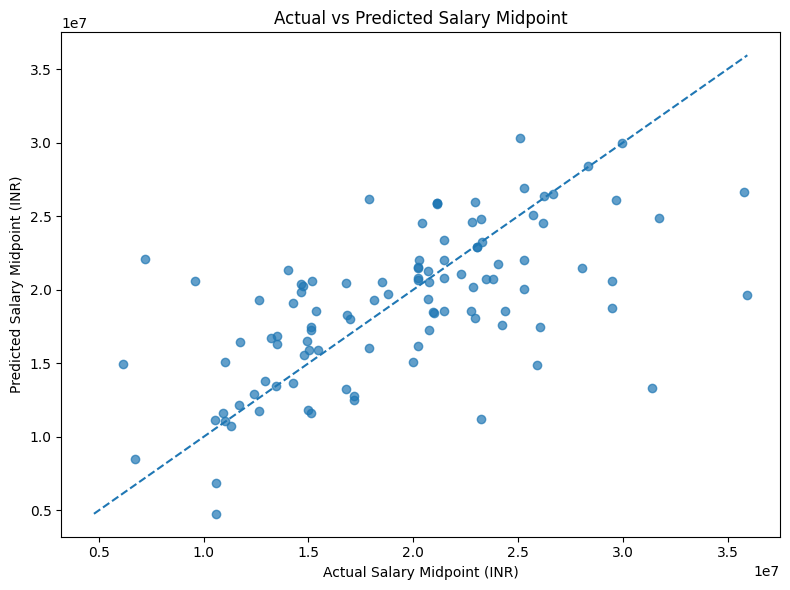

In [186]:

plt.figure(figsize=(8, 6))

plt.scatter(y_holdout,holdout_pred,alpha=0.7)

# Perfect-prediction reference line
min_value = min(y_holdout.min(), holdout_pred.min())
max_value = max(y_holdout.max(), holdout_pred.max())

plt.plot([min_value, max_value], [min_value, max_value],linestyle='--')

plt.xlabel("Actual Salary Midpoint (INR)")
plt.ylabel("Predicted Salary Midpoint (INR)")
plt.title("Actual vs Predicted Salary Midpoint")

plt.tight_layout()
plt.show()

In [187]:
# Actual vs Predicted Salary Midpoint: The scatter plot shows a positive relationship between actual and predicted salary midpoint values. However, substantial dispersion around the ideal prediction line indicates that the model does not capture all salary variation. The model tends to underpredict some higher salary observations and overpredict some lower salary observations.

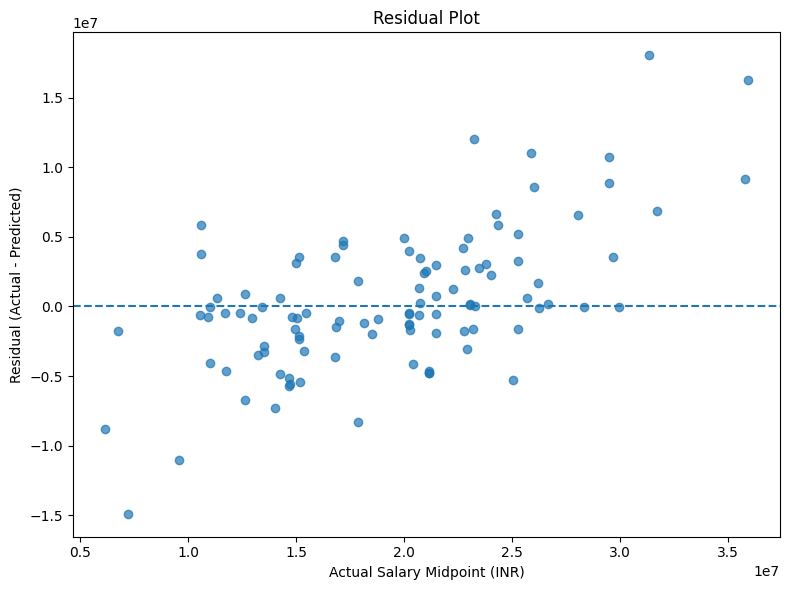

In [188]:
# Calculate residuals
residuals = y_holdout - holdout_pred

plt.figure(figsize=(8, 6))

plt.scatter( y_holdout,residuals,alpha=0.7)

# Zero-error reference line
plt.axhline(y=0,linestyle='--')

plt.xlabel("Actual Salary Midpoint (INR)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")

plt.tight_layout()
plt.show()

In [189]:
# Get transformed feature names
feature_names = final_ridge_model.named_steps['preprocessor'].get_feature_names_out()

# Get Ridge coefficients
coefficients = final_ridge_model.named_steps['model'].coef_

# Create coefficient table
coef_df = pd.DataFrame({'feature': feature_names,'coefficient': coefficients})

# Largest positive and negative coefficients
top_positive = (coef_df.sort_values('coefficient', ascending=False).head(10))

top_negative = (coef_df.sort_values('coefficient', ascending=True).head(10))


In [190]:
print("Top 10 Positive Coefficients:")
print(top_positive.to_string(index=False))

print("\nTop 10 Negative Coefficients:")
print(top_negative.to_string(index=False))

Top 10 Positive Coefficients:
                                                                                                                                                                      feature  coefficient
                                                                                                    categorical__location_clean_San Francisco, CA; Chicago, IL & New York, NY 2.178581e+07
                                                                                                        categorical__location_clean_US-San Francisco, US-Chicago, US-New York 1.784213e+07
                                            categorical__location_clean_New York, NY; San Francisco, CA; Seattle, WA; Los Angeles, CA; Denver, CO; Austin, TX; US-West Remote 1.780077e+07
                                                                       categorical__location_clean_US-Remote, US-San Francisco, US-Chicago, US-New York, US-Seattle, US-Texas 1.455251e+07
                  categorical__loca

In [1]:
import joblib

joblib.dump(final_ridge_model,"salary_ridge_evaluation_model.pkl")

print("Evaluation model saved successfully.")

NameError: name 'final_ridge_model' is not defined

# ML Conclusions

## Objective

The objective of the machine learning stage was to predict the midpoint of the advertised salary range (`salary_mid_inr`) using job-related information available from the posting.

The final salary-prediction dataset contained 524 job postings with complete salary ranges and known currencies. After creating the development and holdout sets and removing one duplicate development observation, 418 observations were used for model development and 105 observations were retained for final holdout evaluation.

## Models Evaluated

The following models were evaluated during development:

- Baseline Mean Predictor
- Random Forest Regressor
- Ridge Regression
- XGBoost Regressor

Title-related and location-related features were evaluated during development to determine whether they added useful predictive information.

## Validation Strategy

Because the salary records were highly concentrated among a small number of companies, ordinary random cross-validation was not considered sufficient for measuring unseen-company generalization.

GroupKFold using `company_name` was therefore used so that validation companies were kept separate from the companies used for training.

For Ridge hyperparameter selection, nested GroupKFold was used. The final model configuration was selected without using the final holdout set.

## Final Model Development Result

The final Ridge model used:

- Company
- Salary currency
- Location
- Posting year
- Posting month
- Title length
- Title word count
- Rule-based title indicators
- Rule-based title function

The selected Ridge regularization parameter was:

`alpha = 0.01`

Under nested GroupKFold evaluation by company, the model obtained:

- MAE: approximately ₹43.89 lakh
- RMSE: approximately ₹59.26 lakh
- R²: approximately 0.105

These results indicate that the model captures some of the salary variation, but prediction becomes considerably more difficult when generalizing to companies not represented in training.

## Final Holdout Result

A separate 105-row random-record holdout was evaluated only after model development was completed.

The holdout results were:

- MAE: approximately ₹36.27 lakh
- RMSE: approximately ₹50.72 lakh
- R²: approximately 0.328

This result should be interpreted as performance on unseen job records from the same overall company pool. It should not be interpreted as an unseen-company generalization score.

## Limitations

1. The salary-prediction dataset is much smaller than the overall job-market dataset. Only 524 of the 7,269 postings had complete salary information with known currency.

2. Salary records are highly concentrated among 10 companies, with most observations coming from a small number of employers.

3. Salary disclosure is not necessarily representative of all job postings, so the salary-model dataset may contain selection bias.

4. Salaries from different currencies were converted to INR using annual exchange-rate values. The resulting target is therefore an INR-normalized salary midpoint rather than the original advertised currency.

5. The model predicts the midpoint of the advertised salary range. It does not predict the exact salary an employee will receive.

6. The company-grouped validation results show substantial variation between companies, indicating that generalization to employers not represented in training remains difficult.

## Overall ML Conclusion

The machine learning component demonstrates that job characteristics such as company, location, currency, and title information contain useful information for estimating advertised salary midpoint. However, the relatively small and company-concentrated salary dataset limits the generalization of the model, particularly to previously unseen employers.

The ML model should therefore be presented as an experimental salary-estimation component of the Job Market Intelligence Platform rather than as a universal salary predictor.